# arXiv Category Pulse

This notebook counts real arXiv submissions by category and decomposes the resulting monthly count series.

Use it for articles such as:

- Which AI fields are actually accelerating?
- Is `cs.CL` still rising after the LLM boom?
- Are biology and finance categories showing durable AI-adjacent growth?

Data source: arXiv API.


In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from examples.hot_trends.data import (
    HotTrendDataError,
    append_real_snapshot,
    build_arxiv_monthly_counts,
    fetch_coingecko_market_chart,
    fetch_defillama_stablecoin_chains,
    fetch_github_repo_metadata,
    fetch_github_stargazers,
    fetch_huggingface_models,
    fetch_wikipedia_pageviews,
    source_audit_table,
)
from examples.hot_trends.decomposition import (
    component_summary,
    decompose_table,
    editorial_priority,
    residual_event_table,
)
from examples.hot_trends.scoring import article_publication_phrasing

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
plt.rcParams.update({"axes.grid": True})

CACHE_DIR = Path("examples/hot_trends/cache")
OUTPUT_DIR = Path("examples/hot_trends/outputs")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_table(df, name):
    path = OUTPUT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"saved: {path.as_posix()}")


## 1. Define the category watchlist


In [2]:
queries = {
    "cs.AI": "cat:cs.AI",
    "cs.LG": "cat:cs.LG",
    "cs.CL": "cat:cs.CL",
    "cs.CV": "cat:cs.CV",
    "stat.ML": "cat:stat.ML",
    "q-bio.QM": "cat:q-bio.QM",
    "q-fin.ST": "cat:q-fin.ST",
    "econ.EM": "cat:econ.EM",
}
watchlist = pd.DataFrame([{"series": k, "query": v} for k, v in queries.items()])
watchlist


,series,query
0,cs.AI,cat:cs.AI
1,cs.LG,cat:cs.LG
2,cs.CL,cat:cs.CL
3,cs.CV,cat:cs.CV
4,stat.ML,cat:stat.ML
5,q-bio.QM,cat:q-bio.QM
6,q-fin.ST,cat:q-fin.ST
7,econ.EM,cat:econ.EM


## 2. Fetch monthly counts

The default window is intentionally modest so the notebook can run without hammering the API. Increase the window for a full article.


In [3]:
START_MONTH = "2025-01-01"
END_MONTH = "2026-05-01"
SLEEP_SECONDS = 3.0

cache_path = CACHE_DIR / f"arxiv_category_counts_{START_MONTH}_{END_MONTH}.csv"
if cache_path.exists():
    counts = pd.read_csv(cache_path, parse_dates=["month"])
else:
    counts = build_arxiv_monthly_counts(queries, start_month=START_MONTH, end_month=END_MONTH, sleep_seconds=SLEEP_SECONDS)
    counts.to_csv(cache_path, index=False)
counts.head(16)


,month,series,query,count,source,access_date,data_quality
0,2025-01-01,cs.AI,cat:cs.AI,2485,arXiv API,2026-05-22,public_api_snapshot
1,2025-02-01,cs.AI,cat:cs.AI,3761,arXiv API,2026-05-22,public_api_snapshot
2,2025-03-01,cs.AI,cat:cs.AI,3406,arXiv API,2026-05-22,public_api_snapshot
3,2025-04-01,cs.AI,cat:cs.AI,3031,arXiv API,2026-05-22,public_api_snapshot
4,2025-05-01,cs.AI,cat:cs.AI,4805,arXiv API,2026-05-22,public_api_snapshot
5,2025-06-01,cs.AI,cat:cs.AI,3949,arXiv API,2026-05-22,public_api_snapshot
6,2025-07-01,cs.AI,cat:cs.AI,3474,arXiv API,2026-05-22,public_api_snapshot
7,2025-08-01,cs.AI,cat:cs.AI,3825,arXiv API,2026-05-22,public_api_snapshot
8,2025-09-01,cs.AI,cat:cs.AI,4260,arXiv API,2026-05-22,public_api_snapshot
9,2025-10-01,cs.AI,cat:cs.AI,4844,arXiv API,2026-05-22,public_api_snapshot


## 3. Audit the source table


In [4]:
audit = source_audit_table(counts, value_col="count", entity_col="series", time_col="month")
audit


,series,first_timestamp,last_timestamp,observations,missing_ratio,min_value,max_value
0,cs.AI,2025-01-01 00:00:00,2026-05-01 00:00:00,17,0.0,2485.0,5018.0
1,cs.CL,2025-01-01 00:00:00,2026-05-01 00:00:00,17,0.0,1312.0,2954.0
2,cs.CV,2025-01-01 00:00:00,2026-05-01 00:00:00,17,0.0,2052.0,4059.0
3,cs.LG,2025-01-01 00:00:00,2026-05-01 00:00:00,17,0.0,3000.0,5054.0
4,econ.EM,2025-01-01 00:00:00,2026-05-01 00:00:00,17,0.0,48.0,112.0
5,q-bio.QM,2025-01-01 00:00:00,2026-05-01 00:00:00,17,0.0,91.0,153.0
6,q-fin.ST,2025-01-01 00:00:00,2026-05-01 00:00:00,17,0.0,16.0,38.0
7,stat.ML,2025-01-01 00:00:00,2026-05-01 00:00:00,17,0.0,344.0,767.0


## 4. Decompose counts with De-Time

For monthly counts, period 12 is the first cycle to test. The method is `MA_BASELINE` by default because it is built into De-Time and keeps the tutorial dependency-light.


In [5]:
components = decompose_table(
    counts,
    entity_col="series",
    time_col="month",
    value_col="count",
    method="MA_BASELINE",
    period=12,
    trend_window=5,
    transform="log1p",
)
components.head(16)


,month,series,observed,trend,season,residual,method,period,transform
0,2025-01-01,cs.AI,7.818430,4.836945,0.918014,2.063471,MA_BASELINE,12,log1p
1,2025-02-01,cs.AI,8.232706,6.440340,0.332074,1.460292,MA_BASELINE,12,log1p
2,2025-03-01,cs.AI,8.133587,8.135864,-0.532397,0.530121,MA_BASELINE,12,log1p
3,2025-04-01,cs.AI,8.016978,8.228472,0.173453,-0.384948,MA_BASELINE,12,log1p
4,2025-05-01,cs.AI,8.477620,8.212601,1.214337,-0.949318,MA_BASELINE,12,log1p
5,2025-06-01,cs.AI,8.281471,8.235799,-0.532441,0.578113,MA_BASELINE,12,log1p
6,2025-07-01,cs.AI,8.153350,8.303855,-0.728619,0.578113,MA_BASELINE,12,log1p
7,2025-08-01,cs.AI,8.249575,8.305471,-0.634010,0.578113,MA_BASELINE,12,log1p
8,2025-09-01,cs.AI,8.357259,8.303947,-0.524801,0.578113,MA_BASELINE,12,log1p
9,2025-10-01,cs.AI,8.485703,8.298107,-0.390518,0.578113,MA_BASELINE,12,log1p


## 5. Rank fields by trend and residual shock


In [6]:
summary = component_summary(components, entity_col="series", time_col="month")
priority = editorial_priority(summary, entity_col="series")
priority


,series,observations,first_timestamp,last_timestamp,trend_last,trend_slope_per_step,cycle_strength_proxy,residual_std,max_abs_residual_z,method,trend_slope_per_step_rank_pct,cycle_strength_proxy_rank_pct,max_abs_residual_z_rank_pct,editorial_priority_score
3,cs.LG,17,2025-01-01 00:00:00,2026-05-01 00:00:00,5.017982,0.007983,-29.718421,0.872881,62.286532,MA_BASELINE,0.625,0.125,0.875,0.63750
4,econ.EM,17,2025-01-01 00:00:00,2026-05-01 00:00:00,2.694439,0.025516,-3.497653,0.479359,6.797311,MA_BASELINE,1.000,0.875,0.250,0.63750
0,cs.AI,17,2025-01-01 00:00:00,2026-05-01 00:00:00,5.078527,0.018128,-21.214366,0.857312,21.466554,MA_BASELINE,0.875,0.375,0.500,0.60625
5,q-bio.QM,17,2025-01-01 00:00:00,2026-05-01 00:00:00,2.826560,-0.003319,-11.445934,0.508898,135.798595,MA_BASELINE,0.125,0.500,1.000,0.59375
2,cs.CV,17,2025-01-01 00:00:00,2026-05-01 00:00:00,4.863904,0.006207,-23.594874,0.844894,39.630611,MA_BASELINE,0.500,0.250,0.750,0.56250
6,q-fin.ST,17,2025-01-01 00:00:00,2026-05-01 00:00:00,1.991595,0.012333,-1.209950,0.305315,2.004959,MA_BASELINE,0.750,1.000,0.125,0.51875
1,cs.CL,17,2025-01-01 00:00:00,2026-05-01 00:00:00,4.579115,0.000606,-10.569187,0.760387,31.452320,MA_BASELINE,0.250,0.625,0.625,0.49375
7,stat.ML,17,2025-01-01 00:00:00,2026-05-01 00:00:00,3.815449,0.003491,-7.626177,0.673733,8.585748,MA_BASELINE,0.375,0.750,0.375,0.45000


## Visualization: arXiv category trend shock scatter

The scatter compares trend slope, shock magnitude, and cycle strength in the editorial priority table.

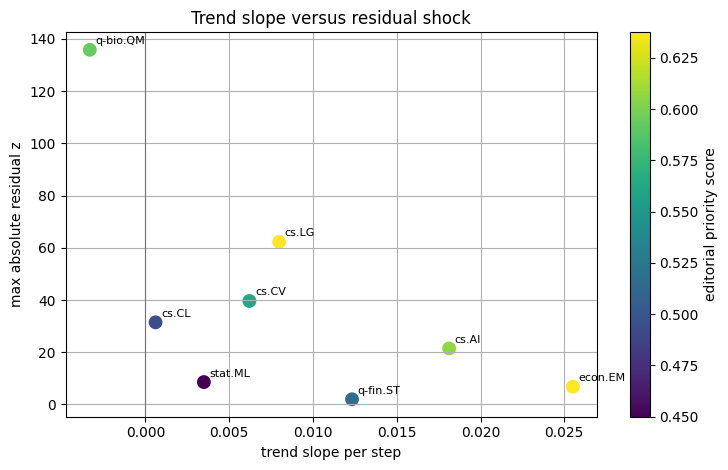

In [7]:
scatter_frame = priority.dropna(subset=["trend_slope_per_step", "max_abs_residual_z"]).copy()
fig, ax = plt.subplots(figsize=(7.5, 4.8))
sizes = 80 + scatter_frame["cycle_strength_proxy"].fillna(0).clip(lower=0) * 260
sc = ax.scatter(
    scatter_frame["trend_slope_per_step"],
    scatter_frame["max_abs_residual_z"],
    s=sizes,
    c=scatter_frame["editorial_priority_score"],
    cmap="viridis",
)
for _, row in scatter_frame.head(8).iterrows():
    ax.annotate(str(row["series"]), (row["trend_slope_per_step"], row["max_abs_residual_z"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.axvline(0, color="0.45", linewidth=0.8)
ax.set_xlabel("trend slope per step")
ax.set_ylabel("max absolute residual z")
ax.set_title("Trend slope versus residual shock")
fig.colorbar(sc, ax=ax, label="editorial priority score")
plt.tight_layout()
plt.show()


## Visualization: arXiv category component panels

Observed and trend lines plus residual bars turn the component table into an inspectable trend narrative.

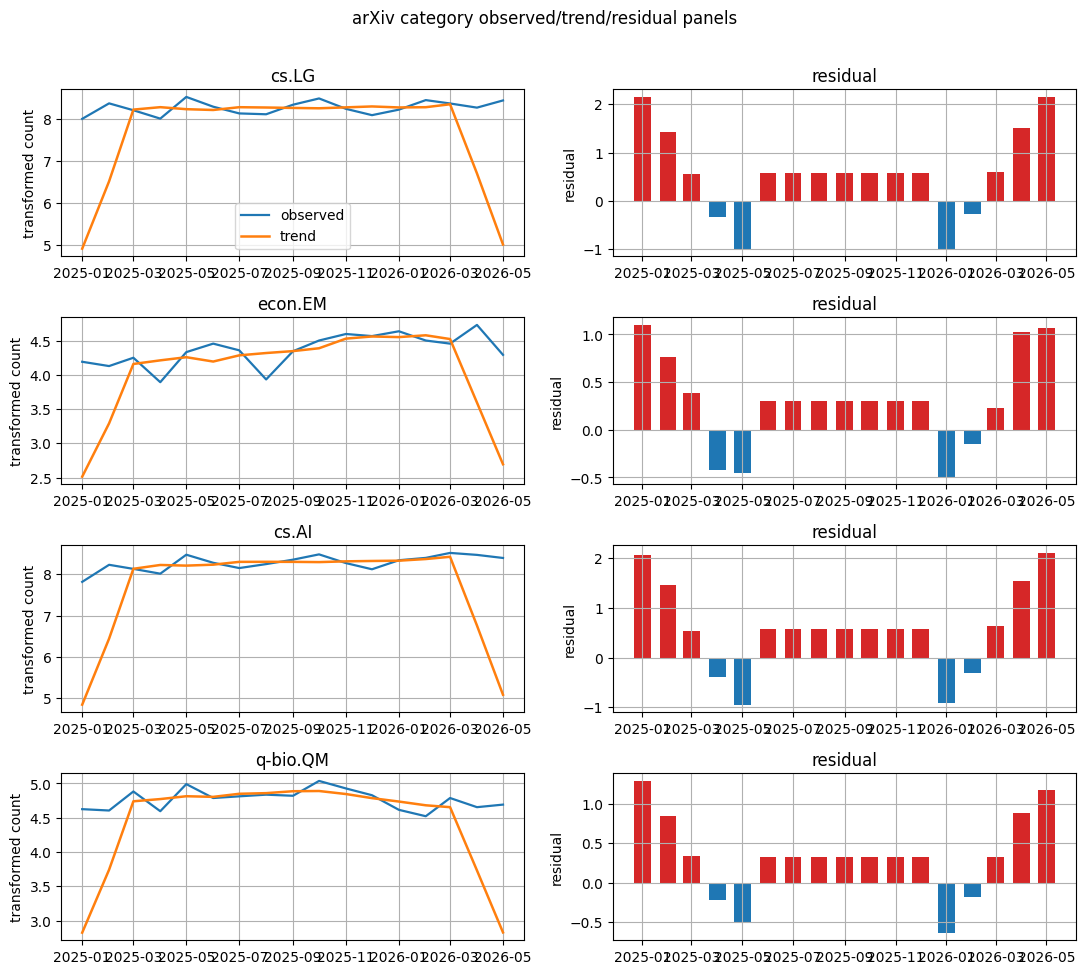

In [8]:
top_entities = priority["series"].head(4).tolist()
fig, axes = plt.subplots(len(top_entities), 2, figsize=(11, max(3.0, 2.4 * len(top_entities))), squeeze=False)
for row, entity in enumerate(top_entities):
    panel = components.loc[components["series"].eq(entity)].sort_values("month").copy()
    panel["month"] = pd.to_datetime(panel["month"])
    axes[row, 0].plot(panel["month"], panel["observed"], label="observed", linewidth=1.6)
    axes[row, 0].plot(panel["month"], panel["trend"], label="trend", linewidth=1.8)
    axes[row, 0].set_title(str(entity))
    axes[row, 1].bar(panel["month"], panel["residual"], color=np.where(panel["residual"] >= 0, "tab:red", "tab:blue"), width=20)
    axes[row, 1].set_title("residual")
    axes[row, 0].set_ylabel("transformed count")
    axes[row, 1].set_ylabel("residual")
axes[0, 0].legend(loc="best")
plt.suptitle("arXiv category observed/trend/residual panels", y=1.01)
plt.tight_layout()
plt.show()


## 6. Top residual events

These rows are article hooks. Causal interpretation requires additional evidence; the rows mark months that do not fit the smooth trend/cycle baseline.


In [9]:
events = residual_event_table(components, entity_col="series", time_col="month", top_n=20)
events


,month,series,observed,trend,season,residual,residual_z,abs_residual_z,method
0,2025-01-01,q-bio.QM,4.624973,2.822589,0.512617,1.289767,135.798595,135.798595,MA_BASELINE
1,2026-01-01,q-bio.QM,4.615121,4.735994,0.512617,-0.633490,-135.798595,135.798595,MA_BASELINE
2,2025-05-01,q-bio.QM,4.990433,4.813606,0.692669,-0.515842,-119.184690,119.184690,MA_BASELINE
3,2026-05-01,q-bio.QM,4.691348,2.826560,0.692669,1.172119,119.184690,119.184690,MA_BASELINE
4,2025-04-01,q-bio.QM,4.595120,4.772203,0.044841,-0.221925,-77.678425,77.678425,MA_BASELINE
5,2026-04-01,q-bio.QM,4.653960,3.730918,0.044841,0.878202,77.678425,77.678425,MA_BASELINE
6,2026-02-01,q-bio.QM,4.521789,4.681335,0.023867,-0.183413,-72.239976,72.239976,MA_BASELINE
7,2025-02-01,q-bio.QM,4.605170,3.741613,0.023867,0.839690,72.239976,72.239976,MA_BASELINE
8,2026-01-01,cs.LG,8.225503,8.277744,0.934998,-0.987239,-62.286532,62.286532,MA_BASELINE
9,2025-01-01,cs.LG,8.006701,4.918570,0.934998,2.153133,62.286532,62.286532,MA_BASELINE


## Visualization: arXiv category residual heatmap

The heatmap shows where residual shocks cluster across entities and time.

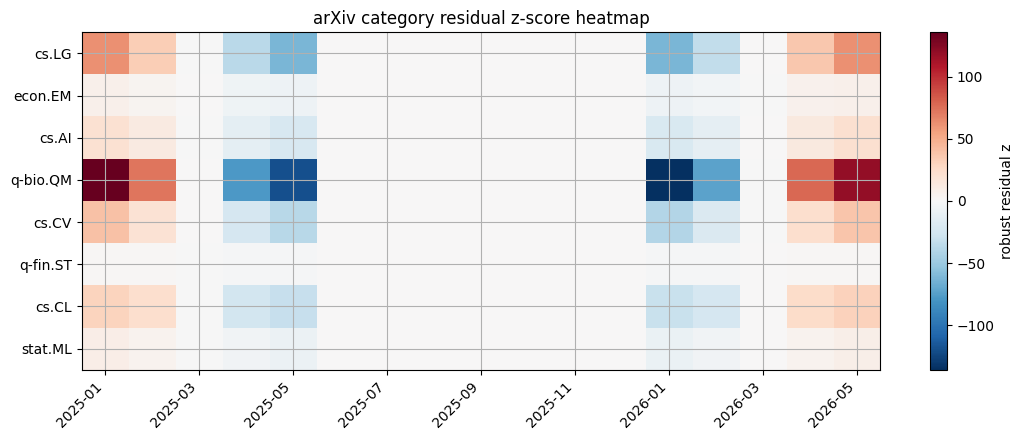

In [10]:
residual_grid = components.copy()
residual_grid["residual_z"] = residual_grid.groupby("series")["residual"].transform(lambda s: (s - s.median()) / (1.4826 * (s - s.median()).abs().median() + 1e-12))
heat = residual_grid.pivot_table(index="series", columns="month", values="residual_z", aggfunc="mean")
heat = heat.reindex(priority["series"].tolist()).dropna(how="all")
values = heat.to_numpy(dtype=float)
absmax = float(np.nanmax(np.abs(values))) if np.isfinite(values).any() else 1.0
fig, ax = plt.subplots(figsize=(11, 4.5))
im = ax.imshow(values, aspect="auto", cmap="RdBu_r", vmin=-absmax, vmax=absmax)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
tick_step = max(1, len(heat.columns) // 8)
xticks = list(range(0, len(heat.columns), tick_step))
ax.set_xticks(xticks)
ax.set_xticklabels([pd.to_datetime(heat.columns[i]).strftime("%Y-%m") for i in xticks], rotation=45, ha="right")
ax.set_title("arXiv category residual z-score heatmap")
fig.colorbar(im, ax=ax, label="robust residual z")
plt.tight_layout()
plt.show()


## 7. Article-ready language


In [11]:
phrasing = article_publication_phrasing()
phrasing


,draft_claim,evidence_based_phrasing
0,This trend predicts the next price move.,This trend summarizes the observed public seri...
1,This model is better because it has more downl...,Downloads are a public adoption proxy interpre...
2,This repo is winning because stars are rising.,Star velocity measures developer attention for...
3,This pageview spike shows the topic matters most.,Pageviews measure public attention during the ...
4,This residual is a buy signal.,This residual marks an event-like deviation fr...


In [12]:
save_table(watchlist, "01_arxiv_category_watchlist")
save_table(audit, "01_arxiv_category_audit")
save_table(priority, "01_arxiv_category_priority")
save_table(events, "01_arxiv_category_residual_events")
save_table(phrasing, "01_arxiv_category_publication_phrasing")


saved: examples/hot_trends/outputs/01_arxiv_category_watchlist.csv
saved: examples/hot_trends/outputs/01_arxiv_category_audit.csv
saved: examples/hot_trends/outputs/01_arxiv_category_priority.csv
saved: examples/hot_trends/outputs/01_arxiv_category_residual_events.csv
saved: examples/hot_trends/outputs/01_arxiv_category_publication_phrasing.csv
